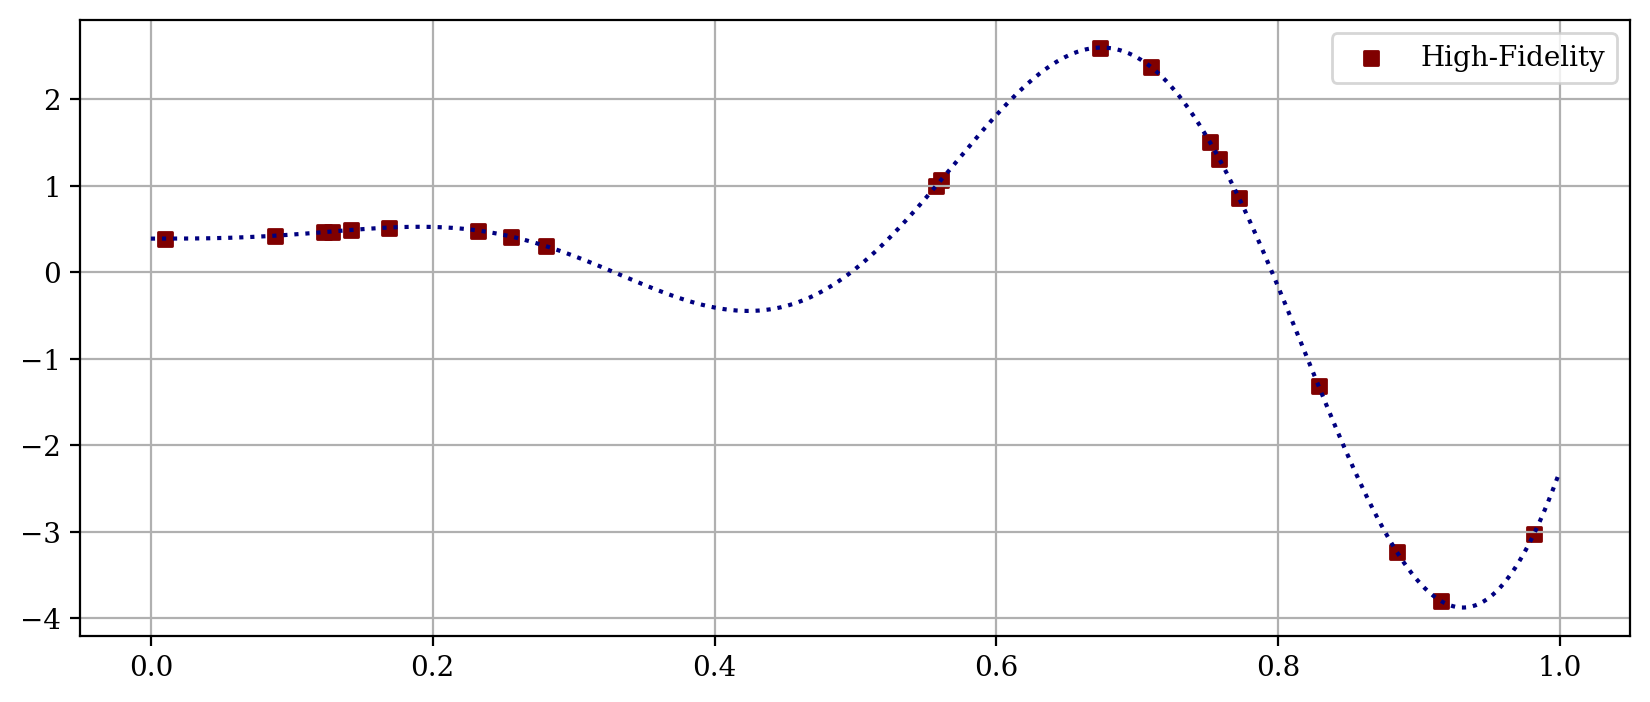

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm import tqdm 
import math 
import jax.numpy as jnp 
from jax.scipy.linalg import cho_solve
from jax import value_and_grad
import jax
from jax import random
jax.config.update("jax_enable_x64", True)
from numpy.random import randn
from numpy import zeros
from copy import deepcopy 
from jax import flatten_util
import itertools

# Plot parameters 
plt.rcParams.update({
    "font.family": "serif",
    'text.latex.preamble': r'\\usepackage{amsmath}',
    'mathtext.fontset': 'cm',
})

# Softplus function for positivity-enforcement
def softplus(x):
    """Softplus activation: log(1 + exp(x))."""
    return jnp.log(1.0 + jnp.exp(x))
def inv_softplus(y):
    """Inverse softplus: maps positive values back to unconstrained space."""
    return jnp.log(jnp.exp(y) - 1.0)

# Functions 
funcs = [
    lambda x: ((5*x**2) * np.sin(12*x))+0.39071933219615607, 
]


# creating high and low-fidelity inputs 
n_train, n_test = 20, 1000
rng_key = random.PRNGKey(seed = 41)
train_key, test_key = random.split(rng_key, 2)
ztrain = random.uniform(train_key, shape = (n_train))
ztest = jnp.linspace(0, 1, n_test)

# Creating high and low-fidelity data 
noise_var = 1e-8
Ytrain = funcs[0](ztrain).ravel() + jnp.sqrt(noise_var)*jnp.array(np.random.randn(n_train))
Ytest = funcs[0](ztest).ravel()

# Creating a polynomial features 
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler, PolynomialFeatures 
input_preprocess = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=True)),
    ("scaler", StandardScaler())
])
Phi_train = input_preprocess.fit_transform(ztrain.reshape(-1,1))

# Plotting the data 
plt.figure(figsize=(10,4), dpi = 200)
plt.scatter(ztrain.ravel(), Ytrain.ravel(), s = 25.0, c = 'maroon', label = "High-Fidelity", marker = 's')
plt.plot(ztest.ravel(), Ytest, linestyle = 'dotted', color = 'navy')
plt.grid()
plt.legend()

In [2]:
# Setup parameters of the neural net 
n_layers, hidden_dim, transformed_dim = 3, 150, 150+1
eps = 1e-10

def polynomial_features(X, degree):
    """
    X: jnp.ndarray of shape (n_samples, n_features)
    degree: highest polynomial degree (int)
    
    Returns:
        jnp.ndarray of shape (n_samples, n_output_features)
    """
    _, n_features = X.shape

    # --- 1. List all exponent tuples for degrees 0..degree ---
    # degree=0 -> intercept term
    exponents = []
    for d in range(degree + 1):
        for comb in itertools.combinations_with_replacement(range(n_features), d):
            # convert e.g. (0,0,2) to exponent vector [2,0,1,...]
            exp = [0] * n_features
            for idx in comb:
                exp[idx] += 1
            exponents.append(jnp.array(exp))

    # --- 2. Compute X^exp for each exponent vector ---
    # Each term: product_j X[:,j] ** exp[j]
    outputs = []
    for exp in exponents:
        term = jnp.prod(X ** exp, axis=1)
        outputs.append(term)

    # Stack all feature columns (n_samples, n_output_features)
    return jnp.stack(outputs, axis=1)

def relu(x):
    return jnp.maximum(0,x)

def rowwise_kron_self(X):
    # X: (n, d)
    n, d = X.shape
    # Expand for broadcasting
    A = X[:, :, None]        # (n, d, 1)
    B = X[:, None, :]        # (n, 1, d)
    # Broadcast multiply → (n, d, d), then reshape each row block
    return (A * B).reshape(n, d * d)

def nn_eval(Phi, p):
    # Assume Phi is in shape (observations x features)
    # Evaluate the linear regression model 
    for layer in p.keys():
        if layer > 0: 
            # Evaluate hidden layer features
            Phi = jnp.hstack((relu(H), jnp.ones((H.shape[0],1))))
        # Evaluate hidden layer state 
        H = Phi @ p[layer]['A']
    
    return H.ravel()

def kl_gaussian(mu_q, mu_p, L_q, L_p):
    k = mu_q.shape[0]
    # ---- log(det Σ) = 2 * sum(log diag(L)) ----
    logdet_q = 2.0 * jnp.sum(jnp.log(jnp.diag(L_q)))
    logdet_p = 2.0 * jnp.sum(jnp.log(jnp.diag(L_p)))
    logdet_ratio = logdet_p - logdet_q

    # ---- trace(Σ_p^{-1} Σ_q) ----
    X = cho_solve((L_p, True), L_q @ L_q.T)  # L_p^{-1} L_q
    trace_term = jnp.trace(X)

    # ---- Mahalanobis distance (μ_p - μ_q)^T Σ_p^{-1} (μ_p - μ_q) ----
    diff = mu_p - mu_q
    v = cho_solve((L_p, True), diff)
    mahalanobis = jnp.dot(diff, v)

    return 0.5 * (trace_term + mahalanobis - k + logdet_ratio)

def kl_gaussian_diag(mu_q, mu_p, L_q, L_p):
    k = mu_q.shape[0]
    # ---- log(det Σ) = 2 * sum(log diag(L)) ----
    logdet_q = 2.0 * jnp.sum(jnp.log((L_q)))
    logdet_p = 2.0 * jnp.sum(jnp.log((L_p)))
    logdet_ratio = logdet_p - logdet_q

    # ---- trace(Σ_p^{-1} Σ_q) ----
    trace_term = jnp.sum(L_q**2 / L_p**2)

    # ---- Mahalanobis distance (μ_p - μ_q)^T Σ_p^{-1} (μ_p - μ_q) ----
    diff = mu_p - mu_q
    mahalanobis = jnp.sum(diff**2 / L_p**2)

    return 0.5 * (trace_term + mahalanobis - k + logdet_ratio)


def pos_diagonal(M):
    diag = jnp.diag(M)
    diag_sp = softplus(diag) + eps
    return M - jnp.diag(diag) + jnp.diag(diag_sp)

def likelihood(key, Phi, Y, q_mu, q_L, unravel_fn, noise_var):
    # Sampling from the variational distribution 
    sampled_params = q_mu + q_L * random.normal(key, shape=(q_mu.shape[0]))
    # Re-raveling the neural network parameters 
    nn_params = unravel_fn(sampled_params)
    # Computing the misfit between model prediction and data 
    error = (Y - nn_eval(Phi, nn_params)).ravel() 
    # Computing the 2-norm of the data fit term
    data_fit = jnp.inner(error, error) / noise_var 
    scalar_term = Phi.shape[0] * jnp.log(2*math.pi*noise_var)
    return -0.5*(data_fit + scalar_term)

def neg_elbo(p, Phi, Y, N_mc, unravel_fn, seed=42):
    # Ensuring positive definiteness of Cholesky factors
    p_L = softplus(p['p_L']) + eps
    q_L = pos_diagonal(p['q_L'])
    # p_L = pos_diagonal(p['p_L'])
    # q_L = pos_diagonal(p['q_L'])

    # Generating random numbers 
    key = random.PRNGKey(seed)
    keys = random.split(key, num=N_mc)
    # Obtaining random likelihood draws 
    likelihood_term = jnp.mean(jax.vmap(
        lambda key: likelihood(
            key, Phi, Y, p['q_mu'], q_L, unravel_fn, softplus(p['noise_var'])
        )
    )(keys))

    # Computing KL divergence term 
    kl_term = kl_gaussian(p['q_mu'], p['p_mu'], q_L, jnp.diag(p_L))

    return -(likelihood_term - kl_term)

p = {
    'nn':{
        0:{
            'A':np.random.randn(Phi_train.shape[1], hidden_dim)
        }, 
        1:{
            'A':np.random.randn(transformed_dim, hidden_dim)
        },
        2:{
            'A':np.random.randn(transformed_dim, hidden_dim)
        },
        3:{
            'A':np.random.randn(transformed_dim)
        }
    },
    'noise_var':inv_softplus(noise_var)
}
# Flattening the parameters into a single vector
params, unravel_fn = flatten_util.ravel_pytree(p['nn'])
# Generating variational and prior distributions from flattened parameters 
scalar = 1.0e0
p['q_mu'] = 1e-1*np.random.randn(params.shape[0])
p['q_L'] = inv_softplus(1e-5*jnp.ones(params.shape[0]))
p['p_mu'] = jnp.zeros(params.shape[0])
p['p_L'] = jnp.diag(inv_softplus(1e0* jnp.ones(params.shape[0])))

N_mc = 10
grad_func = value_and_grad(jax.jit(lambda p: neg_elbo(p, Phi_train, Ytrain, N_mc, unravel_fn, seed=42)))
loss, grad = grad_func(p)
print("Initial Loss: %.4e" % loss)
best_loss, best_p = loss, deepcopy(p)

ValueError: The arguments to solve must have shapes a=[..., m, m] and b=[..., m, k] or b=[..., m]; got a=(46351,) and b=()

In [122]:
# Making momentum PyTree
p = deepcopy(dict(best_p))
v = jax.tree.map(jnp.zeros_like, p)

epochs, beta = int(5e5), 0.995
lr = 1e-11
iterator = tqdm(range(epochs))

for iter in iterator:
    loss, grad = grad_func(p)
    iterator.set_postfix_str("Loss: %.4e" % (loss))
    # Updating the parameters
    v = jax.tree.map(lambda v, g: beta * v - lr * g, v,grad)
    # p['p_L'] = jnp.tril(p['p_L'] + v['p_L']) 
    p['p_L'] += v['p_L']
    p['p_mu'] += v['p_mu'] 
    p['q_mu'] += v['q_mu'] 
    p['q_L'] += v['q_L']
    # p['q_L'] = jnp.tril(p['p_L'] + v['q_L'])
    # p['noise_var'] += v['noise_var'] 

    if loss < best_loss: 
        best_loss = loss 
        best_p = deepcopy(dict(p))

  0%|          | 0/500000 [00:00<?, ?it/s]

  0%|          | 1076/500000 [00:21<2:46:25, 49.97it/s, Loss: 5.1131e+05]


KeyboardInterrupt: 

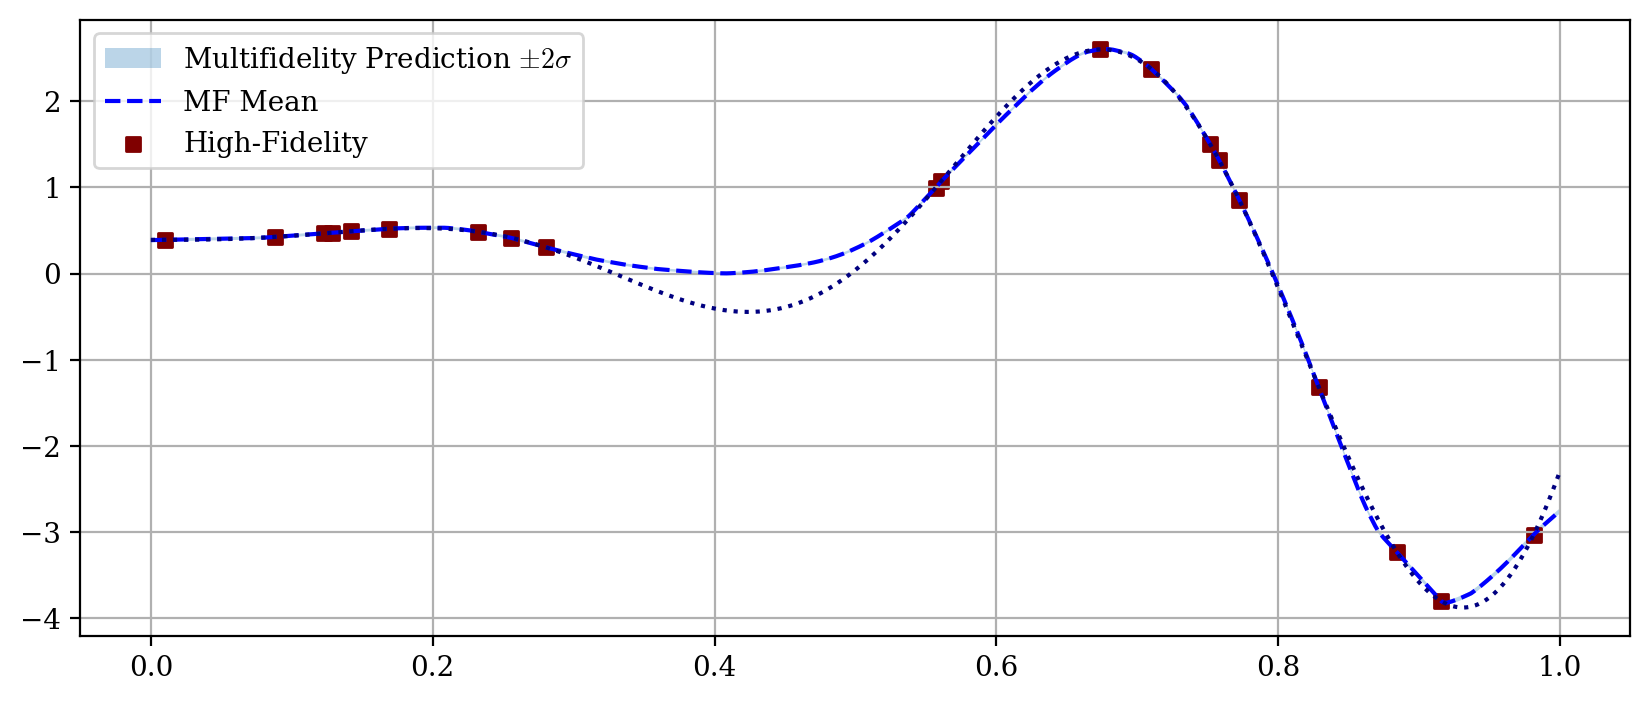

In [123]:
@jax.jit
def single_prediction(key, Phi, q_mu, q_L):
    # Sampling from the variational distribution 
    sampled_params = q_mu + q_L @ random.normal(key, shape=(q_mu.shape[0]))
    # Re-raveling the neural network parameters 
    nn_params = unravel_fn(sampled_params)
    # Evaluating the neural net 
    return nn_eval(Phi, nn_params)

N_mc_test = 100 
key = random.PRNGKey(seed=42)
keys = random.split(key, N_mc_test)

preds = jax.vmap(
    lambda key: single_prediction(
        key,
        input_preprocess.transform(ztest.reshape(-1,1)), 
        best_p['q_mu'],
        jnp.diag(softplus(best_p['q_L']) + eps)
    )
)(keys)

pred_mean = preds.mean(axis=0)
preds_conf = 2*jnp.sqrt(preds.std(axis=0))

nn_params = unravel_fn(best_p['q_mu'])

yhat = nn_eval(input_preprocess.transform(ztest.reshape(-1,1)), nn_params)

# Plotting the data 
plt.figure(figsize=(10,4), dpi = 200)
plt.fill_between(ztest, pred_mean - preds_conf, pred_mean + preds_conf, alpha = 0.3, label = "Multifidelity Prediction $\pm 2 \sigma$")
plt.plot(ztest, pred_mean, color = 'blue', linestyle = 'dashed', label = "MF Mean")
plt.scatter(ztrain.ravel(), Ytrain.ravel(), s = 25.0, c = 'maroon', label = "High-Fidelity", marker = 's')
plt.plot(ztest.ravel(), Ytest, linestyle = 'dotted', color = 'navy')
plt.grid()
plt.legend()
# plt.ylim(-10,10)